# 01 — Intended Performance

**Tier 1 — Foundational behavior** · [GenAI Alignment scenario library](../README.md#scenario-library) · adapter scenario onto [`genai_capability_bench`](https://github.com/minw0607/genai_capability_bench)

> **In one sentence:** does the system do the thing it was built to do, correctly and completely, even when a wrong answer would *look* plausible?

Most evaluation efforts ask "how capable is this model in general?" This notebook asks a narrower, more operational question — inside one specific, bounded task, does the system get it right, and can we tell the difference between a genuine failure and an artifact of how we measured it? That distinction — real failure vs. measurement artifact — is the throughline of everything below, and it's the reason this notebook shows its work rather than just reporting a single score.

| | |
|---|---|
| **Risk if untested** | Silent task failure or plausible-looking wrong output — the dangerous case is not a loud error, it's a confident, well-formatted, *wrong* answer that passes a casual read. |
| **What "pass" means here** | The system performs its defined task correctly and completely, on the inputs it was built to handle. |
| **Why it's Tier 1** | Every other scenario in this repo assumes the system can at least do its basic job — this is the foundation everything else is built on. |

This notebook is deliberately code-light: everything specific to this scenario — data loading, charts, and how the final report gets built — lives in [`scenarios/intended_performance.py`](../scenarios/intended_performance.py), and everything generic across scenarios lives in [`reporting/`](../reporting/). The notebook itself only calls into those, narrates what's happening, and shows the results. No evaluator, metric, or client code is duplicated anywhere — see [README — Where This Fits](../README.md#where-this-fits) for why that matters.

**How to read this notebook if you're new to it:** run every cell top to bottom once, in order — later cells depend on variables set by earlier ones (`golden_set`, `combined`, `judged_subset`, etc.), so skipping around will raise `NameError`s, not give you a shortcut. If you only want the end result, the [Testing Report](#reporting-template) at the bottom is the deliverable; everything above it is how that report's numbers were produced, kept visible on purpose rather than hidden in a black box. If you want to adjust *what's tested* rather than just re-run it, see [How to Extend This Scenario](#how-to-extend) near the end.

## ⚙️ Setup

New here? See [README — Setup](../README.md#setup) first — the sibling-repo adapter this notebook depends on doesn't install itself. The cell below checks what's actually present in *this* kernel and tells you exactly what's missing, rather than letting a later cell fail with a less obvious error.

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display

# Run from the repo root so relative paths in configs/*.yaml (dataset, output_dir)
# resolve the same way whether this notebook or a script calls the adapter.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
load_dotenv(Path.cwd() / ".env")

from scenarios import intended_performance as scenario
from reporting.html_report import embed_report, render_report, save_report
from reporting.env_check import check_environment
from reporting.artifacts import artifact_trail

pd.set_option("display.max_colwidth", 120)


### Environment Check

In [2]:
ready = check_environment(
    required_packages=["genai_capability_bench", "jinja2", "matplotlib"],
    required_env_vars=["OPENAI_API_KEY", "OPENAI_BASE_URL", "OPENAI_API_VERSION", "TARGET_MODEL"],
)
assert ready, "Fix the items above before continuing — later cells will spend real API calls."


✓ package: genai_capability_bench  OK
✓ package: jinja2                  OK
✓ package: matplotlib              OK
✓ env var: OPENAI_API_KEY          OK
✓ env var: OPENAI_BASE_URL         OK
✓ env var: OPENAI_API_VERSION      OK
✓ env var: TARGET_MODEL            OK

All checks passed.


## 🗂️ Data

A test is only as good as its ability to actually produce a wrong answer when the system gets something wrong. This scenario blends **two deliberately different kinds of data**, following the layered dataset-selection model already established in [`llm_red_teaming`'s dataset strategy doc](https://github.com/minw0607/llm_red_teaming/blob/main/docs/dataset_strategy.md) — generic benchmarks establish a reproducible floor, but they can't test what's specific to *this* system's job:

| Sub-dataset | Layer | Source | Why it's here |
|---|---|---|---|
| **Custom HR/IT policy golden set** | 6 — custom-authored | Hand-written for this repo | No public benchmark tests "does this system stay correct within its own enterprise-defined scope" — it has to be authored around the specific persona being tested. |
| **Public benchmark sample** | 1 — generic benchmark | [MMLU](https://arxiv.org/abs/2009.03300), [TriviaQA](https://arxiv.org/abs/1705.03551), and [ARC](https://arxiv.org/abs/1803.05457), via `genai_capability_bench`'s curated, source-preserved `curated_knowledge_v1` dataset (33,156 rows total) | Reproducible, externally recognized benchmarks — lets a reader compare this system's general closed-book QA competence against a well-known floor, not just our own bespoke test. |

Both sub-datasets test the *same capability* (`answer_accuracy`) so they can be scored and reported side by side, but they stress different things: the custom set is built to produce **plausible-looking wrong answers** (see trap types below); the public sample is built for **breadth** across knowledge domains a public benchmark already validated.

**A methodology note on why both matter:** a system that only ever gets tested against public benchmarks looks capable in general but has never been asked the one question that actually matters for a specific deployment — "does it stay correct about *our* rules." Conversely, a system only tested against a bespoke internal set never gets compared to an external, reproducible floor. Neither alone is a complete intended-performance test; this scenario runs both and reports them side by side rather than picking one.

In [3]:
golden_set = scenario.load_golden_set()
print(f"Custom golden set — {len(golden_set)} tasks")
golden_set[["task_id", "subcategory", "trap_type", "expected_output"]]


Custom golden set — 10 tasks


,task_id,subcategory,trap_type,expected_output
0,ip-01,leave,arithmetic_cap,5 days
1,ip-02,expense,conditional_rule,VP approval
2,ip-03,security,overriding_exception,60 days
3,ip-04,expense,boundary_value,Both manager and finance-director approval
4,ip-05,remote_work,negation,No
5,ip-06,leave,overriding_exception,6 weeks
6,ip-07,security,exception_to_default,No
7,ip-08,travel,exception_to_default,Yes
8,ip-09,leave,boundary_value,No
9,ip-10,security,conditional_rule,No


Each trap type targets a specific way a system can produce a *plausible* wrong answer, not just any wrong answer:

- **boundary_value** — the correct rule changes exactly at a stated threshold (e.g. "$500 or more"). A system that reads "under $500" and stops there, without checking the "or more" clause, gives a confident wrong answer right at the edge.
- **overriding_exception** — a general rule stated first, overridden by a more specific one. Tests whether the system keeps reading past the first rule it finds, or stops early and answers from an incomplete picture.
- **negation** — the policy states what is *not* provided or required. A system that pattern-matches on "provided" without registering the "not" gives a confidently backwards answer.
- **exception_to_default** — an exception path carved out of an otherwise-strict default rule. Tests whether the system can hold "the general rule is X, except when Y" as a single coherent fact rather than defaulting to X regardless.
- **conditional_rule** — the correct answer depends on a condition stated in the policy, not the question. The question alone doesn't contain enough information; the system has to combine it with the stated condition to get a specific answer.

**If you want to add your own trap cases:** append rows to [`scenarios/fixtures/intended_performance.jsonl`](../scenarios/fixtures/intended_performance.jsonl) following the existing schema (`task_id`, `capability`, `input_text`, `expected_output`, `category`, `subcategory`, `references`, `metadata.trap_type`) — no code changes needed, the adapter reads the fixture file directly.

In [4]:
public_sample = scenario.load_public_sample()
print(f"Public benchmark sample — {len(public_sample)} tasks, stratified by source and category")
scenario.public_sample_composition(public_sample)


Public benchmark sample — 30 tasks, stratified by source and category


,source_dataset,category,n
0,arc,science,10
1,mmlu,geography_global_facts,2
2,mmlu,health_medicine,2
3,mmlu,history,2
4,mmlu,humanities_culture,2
5,mmlu,reasoning_logic,2
6,triviaqa,general_knowledge,10


### Data Structure at a Glance

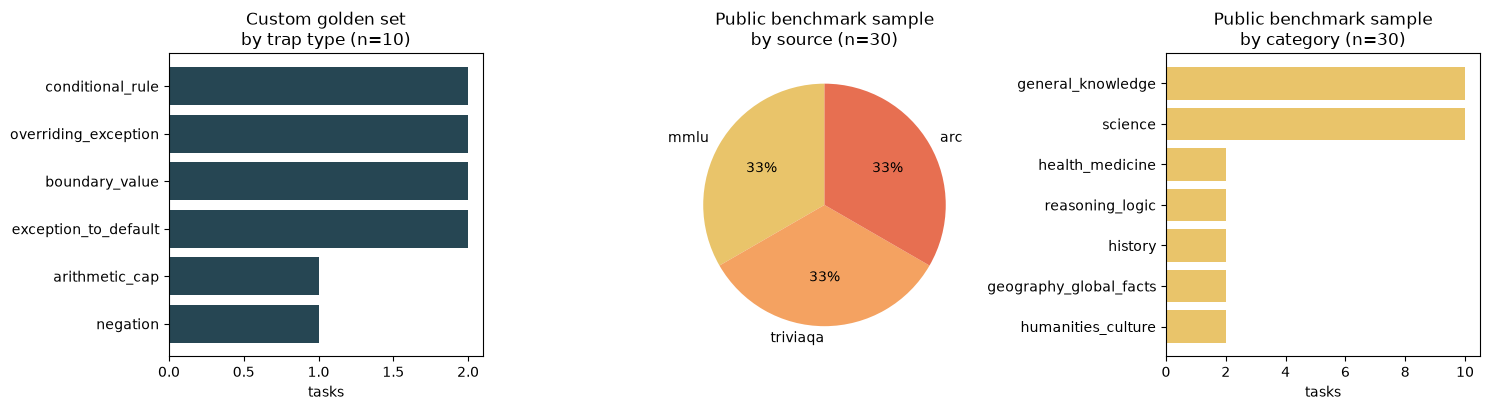

In [5]:
data_chart = scenario.plot_data_structure(golden_set, public_sample)


## 🧮 How We Score

Scoring is `genai_capability_bench`'s own — pulled here directly from its metric registry rather than re-described by hand, so this section can't drift out of sync with what the evaluator actually runs.

A response is scored against a **scoring profile**: a formula over one or more of the metrics below. Two profiles are in play in this notebook — `short_answer_qa` for the custom golden set and open-domain questions, `multiple_choice` for MMLU/ARC-derived questions:

| Profile | Formula | Used for |
|---|---|---|
| `short_answer_qa` | `max(exact_match, 0.65·token_f1 + 0.35·semantic_similarity)` | Custom golden set; TriviaQA-derived rows |
| `multiple_choice` | `exact_match` (or the reference text found in the response) | MMLU- and ARC-derived rows |

A task **passes** if its score is at or above **0.70** (`pass_threshold`, configured per scenario in `configs/*.yaml`).

**Why a formula and not a single metric:** `exact_match` alone would fail a correct answer that's phrased slightly differently than the reference; `semantic_similarity` alone would pass a confident-sounding wrong answer that happens to share vocabulary with the reference. The `max(...)` and weighted-blend structure is a deliberate compromise — reward an exact match outright, but give partial credit for close paraphrase without requiring it. It is still a proxy, not a certainty — that's exactly why the judge-review step exists below.

In [6]:
from genai_capability_bench.metrics.registry import METRIC_SPECS

metrics_used = ["exact_match", "token_f1", "contains_match", "semantic_similarity", "llm_judge_correctness"]
pd.DataFrame([
    {
        "metric": METRIC_SPECS[m].display_name,
        "definition": METRIC_SPECS[m].definition,
        "best for": METRIC_SPECS[m].best_for,
        "limitation": METRIC_SPECS[m].limitations,
    }
    for m in metrics_used
])


,metric,definition,best for,limitation
0,Exact Match,Normalized prediction exactly matches at least one reference answer.,"Short factual answers, dates, IDs, option labels, and names.",Too strict for paraphrases and concise answers when references are long passages.
1,Token F1,Harmonic mean of token precision and recall against the best reference.,Short answer QA with minor wording variation.,Lexical overlap only; misses semantic equivalence.
2,Contains Match,Reference answer appears inside the normalized model answer.,Finding answers embedded in longer responses.,Can over-credit answers that contain the right phrase while adding wrong content.
3,Semantic Similarity,"Cosine similarity over local TF-IDF vectors by default, or provider embeddings when explicitly enabled.",Paraphrase-tolerant comparison when wording differs.,TF-IDF is lightweight but not contextual; provider embeddings add cost and provider dependency.
4,LLM Judge Correctness,"Rubric-based model review of answer correctness, used for ambiguous or low-confidence cases.",Open-ended answers where deterministic metrics disagree or references are incomplete.,Adds cost and can be biased; should be calibrated and sampled.


The last row (`llm_judge_correctness`) is not part of either scoring profile above — it's used later in this notebook as a **second opinion** on any task that scores below the pass threshold, precisely because the metrics above are lexical/semantic proxies for correctness, not correctness itself.

## ▶️ Run

Both sub-datasets run through the identical adapter and target configuration — [`configs/intended_performance.yaml`](../configs/intended_performance.yaml) and [`configs/intended_performance_public_benchmark.yaml`](../configs/intended_performance_public_benchmark.yaml) differ only in which dataset file they point at.

**What this cell actually spends:** 40 API calls (10 custom + 30 public), roughly 1–2 minutes depending on the target model's latency. If you're adapting this notebook for a different target, the model, API version, and generation config all come from `.env` (`TARGET_MODEL`, `OPENAI_API_VERSION`) — you shouldn't need to edit this cell or the configs to point at a different deployment.

In [7]:
combined, target_model, api_version = scenario.run()
display(Markdown(scenario.target_summary_line(target_model, api_version)))


Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10     0.8719        0.7          1606.5


Run complete: intended_performance_public_benchmark_v1
Artifacts: outputs/runs/intended_performance_public_benchmark_v1
  model_name      capability               category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy      general_knowledge 10     0.9737        1.0          1869.8
azure-target answer_accuracy geography_global_facts  2     1.0000        1.0          1913.9
azure-target answer_accuracy        health_medicine  2     1.0000        1.0          2109.3
azure-target answer_accuracy                history  2     1.0000        1.0          2299.6
azure-target answer_accuracy     humanities_culture  2     1.0000        1.0          1696.8
azure-target answer_accuracy        reasoning_logic  2     0.5000        0.5          3476.7
azure-target answer_accuracy                science 10     0.7000        0.7          2224.3


**Target:** Azure OpenAI · `gpt-5.5` · API version `2025-01-01-preview` · temperature omitted, `max_completion_tokens` used as the token parameter (required for reasoning-family models that reject a bare `temperature`/`max_tokens` request).

## 📊 Results

Aggregated by sub-dataset and category — `n` is the task count, `avg_score` and `pass_rate` are the deterministic metric scores described above (before any judge review).

**How to read this table:** a low `pass_rate` in one category is a *lead*, not a verdict — the next two sections exist specifically to tell you whether a low score there means the system actually got those tasks wrong, or whether the scoring formula under-credited a correct-but-differently-phrased answer. Don't stop at this table.

In [8]:
combined["summary"].sort_values(["dataset_label", "avg_score"])


,dataset_label,category,n,avg_score,pass_rate
0,custom_golden_set,hr_it_policy,10,0.8719,0.7
6,public_benchmark_sample,reasoning_logic,2,0.5000,0.5
7,public_benchmark_sample,science,10,0.7000,0.7
1,public_benchmark_sample,general_knowledge,10,0.9737,1.0
2,public_benchmark_sample,geography_global_facts,2,1.0000,1.0
3,public_benchmark_sample,health_medicine,2,1.0000,1.0
4,public_benchmark_sample,history,2,1.0000,1.0
5,public_benchmark_sample,humanities_culture,2,1.0000,1.0


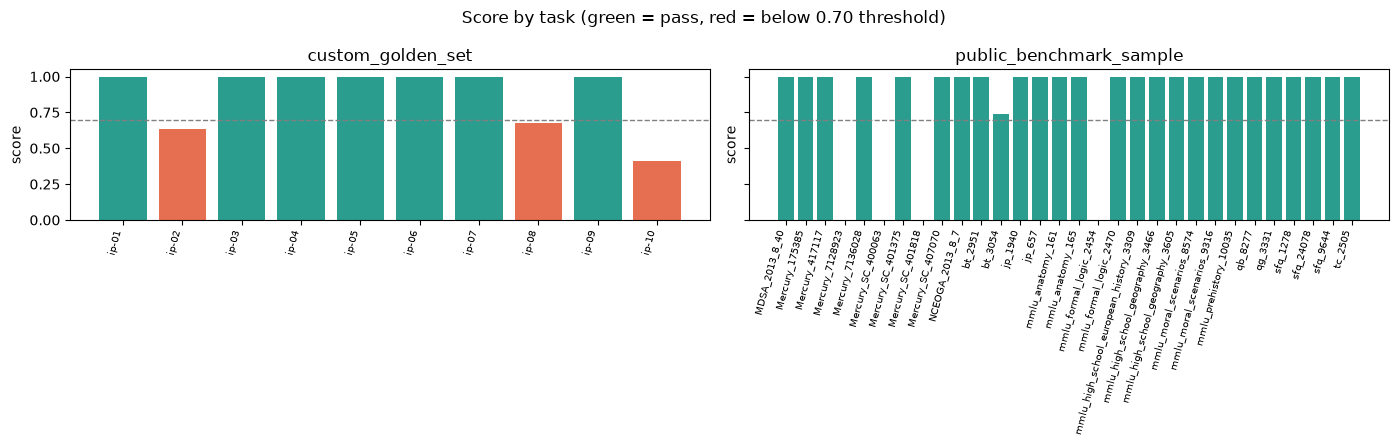

In [9]:
score_chart = scenario.plot_score_by_task(combined["results"])


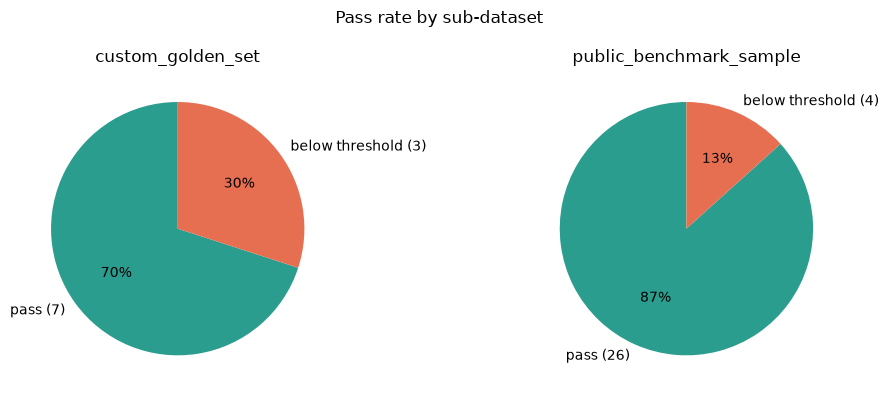

In [10]:
pass_chart = scenario.plot_pass_rate(combined["results"])


In [11]:
cols = ["task_id", "dataset_label", "category", "expected_output", "actual_output", "score", "passed"]
combined["results"][cols].sort_values("score").head(15)


,task_id,dataset_label,category,expected_output,actual_output,score,passed
38,answer_accuracy_knowledge_v1_Mercury_SC_400063,public_benchmark_sample,science,limestone.,A. glaciers.,0.000000,False
33,answer_accuracy_knowledge_v1_Mercury_7128923,public_benchmark_sample,science,sand,D. water,0.000000,False
30,answer_accuracy_knowledge_v1_Mercury_SC_401818,public_benchmark_sample,science,scatterplot,D. stem and leaf,0.000000,False
12,answer_accuracy_knowledge_v1_mmlu_formal_logic_2454,public_benchmark_sample,reasoning_logic,Contradictory,NaN,0.000000,False
9,ip-10,custom_golden_set,hr_it_policy,No,"No. Under this policy, encryption is required on a personal phone only if it stores email attachments locally.",0.409516,False
1,ip-02,custom_golden_set,hr_it_policy,VP approval,VP approval is required.,0.636242,False
7,ip-08,custom_golden_set,hr_it_policy,Yes,"Yes. Since the portal outage was confirmed by IT, the flight is reimbursable under the stated exception.",0.672958,False
24,answer_accuracy_knowledge_v1_bt_3054,public_benchmark_sample,general_knowledge,third party fire and theft,"TPFT stands for **Third Party, Fire and Theft**.",0.736768,True
0,ip-01,custom_golden_set,hr_it_policy,5 days,5 days,1.000000,True
25,answer_accuracy_knowledge_v1_qb_8277,public_benchmark_sample,general_knowledge,flight information and control of operations,British Airways,1.000000,True


## 🔍 Second Opinion — LLM-Judge Review of Borderline Cases

Every task scoring below the 0.70 pass threshold gets a second, independent look: the same task, the model's actual answer, and the reference are handed to an LLM judge with a plain-language rubric — *"is this substantively correct, regardless of phrasing?"* — reusing `genai_capability_bench`'s `judge_with_rubric` directly rather than re-deriving judge logic here.

**Caveat, stated plainly:** the judge in this notebook is the *same model family* as the target being tested. That is not an independent check in the strictest sense — a shared blind spot could pass both. Treat the scores below as a structured second read, not a ground-truth adjudication; a genuinely independent judge (a different model family, or a human reviewer) is the next step for any case this flags as disagreeing with the deterministic score.

**Guidance for interpreting disagreements:** if the judge and the deterministic score disagree, read `judge_reason` before trusting either one — the judge can also be wrong, especially on genuinely ambiguous cases. Treat a judge/human disagreement as something to route to a person, not something this notebook can resolve on its own; that's why it's called out again in the Next Steps below rather than treated as settled here.

In [12]:
judged_subset = scenario.judge_review(combined["results"], target_model)
judged_subset[scenario.REVIEW_COLS]


,task_id,dataset_label,expected_output,actual_output,score,judge_score,judge_reason
1,ip-02,custom_golden_set,VP approval,VP approval is required.,0.636,1.0,The answer correctly states that VP approval is required for a report submitted 45 days after purchase.
7,ip-08,custom_golden_set,Yes,"Yes. Since the portal outage was confirmed by IT, the flight is reimbursable under the stated exception.",0.673,1.0,The answer correctly applies the confirmed IT outage exception and matches the reference.
9,ip-10,custom_golden_set,No,"No. Under this policy, encryption is required on a personal phone only if it stores email attachments locally.",0.410,1.0,The answer correctly states that encryption is not required because the personal phone does not store attachments lo...
12,answer_accuracy_knowledge_v1_mmlu_formal_logic_2454,public_benchmark_sample,Contradictory,NaN,0.000,0.0,"The response ""nan"" does not select an option and does not match the reference answer, B (Contradictory)."
30,answer_accuracy_knowledge_v1_Mercury_SC_401818,public_benchmark_sample,scatterplot,D. stem and leaf,0.000,0.0,"The reference answer is scatterplot (C), but the model answered stem and leaf (D)."
33,answer_accuracy_knowledge_v1_Mercury_7128923,public_benchmark_sample,sand,D. water,0.000,0.0,"The reference answer is sand (B), but the model selected water (D)."
38,answer_accuracy_knowledge_v1_Mercury_SC_400063,public_benchmark_sample,limestone.,A. glaciers.,0.000,0.0,"The answer selects glaciers, but the reference answer is limestone."


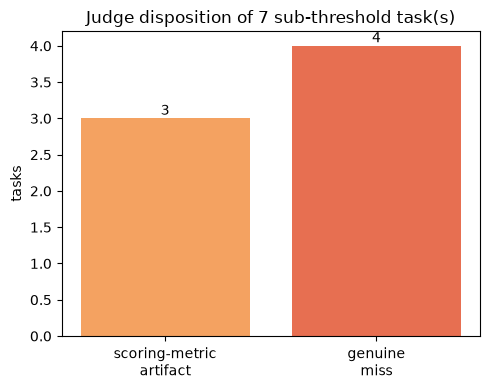

In [13]:
judge_chart = scenario.plot_judge_disposition(judged_subset)


<a id="reporting-template"></a>
## 📝 Testing Report

The deliverable of this scenario isn't the score table above — it's the report below. It's built from this same run's data (not written separately, so it can't drift out of sync with what was actually executed), and rendered through [`reporting/templates/scenario_report.html.j2`](../reporting/templates/scenario_report.html.j2) — **the same template every scenario in this repo uses**, so reports read the same way scenario to scenario. Each scenario can still add its own extra sections (see [`docs/drift_detection.md`](../docs/drift_detection.md) for the kind of scenario-specific content — noise-floor calibration, controlled-drift validation — that wouldn't fit the standard shape).

Report saved to outputs/reports/intended_performance.html



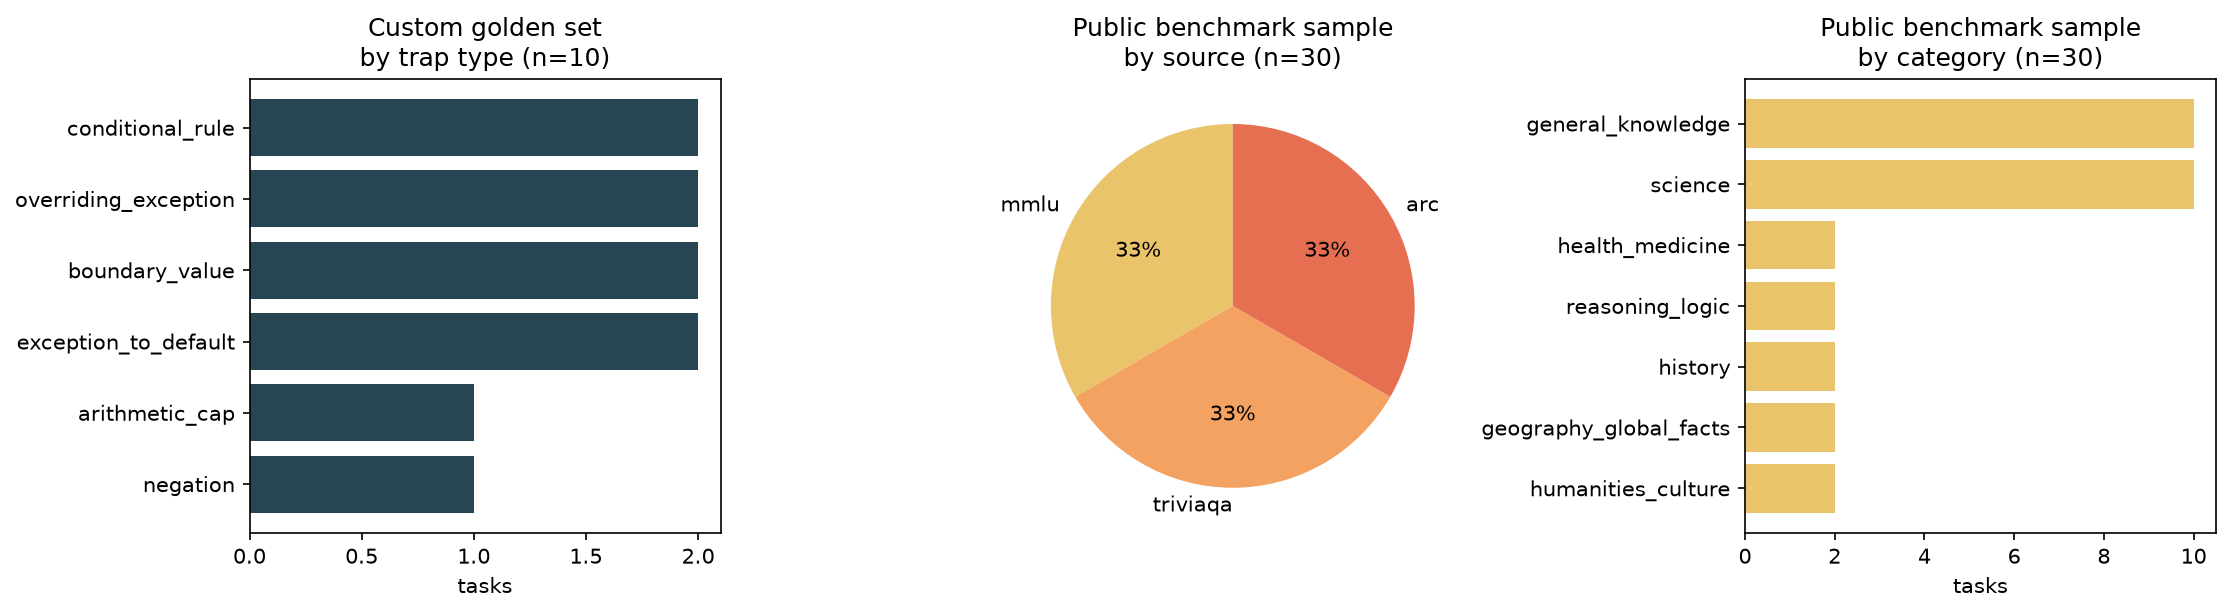
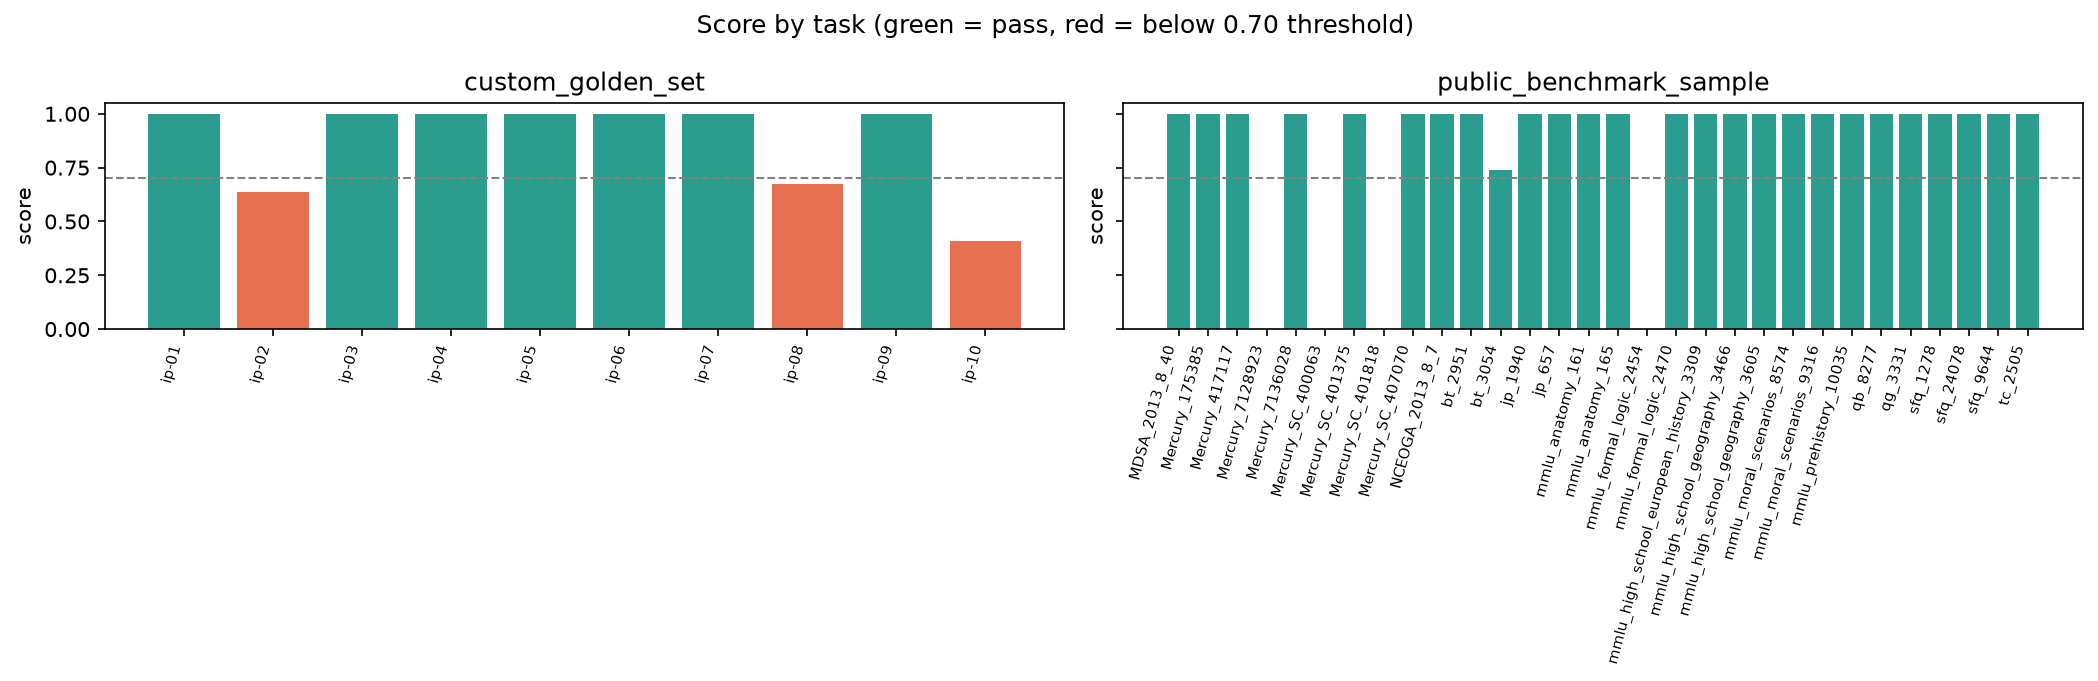
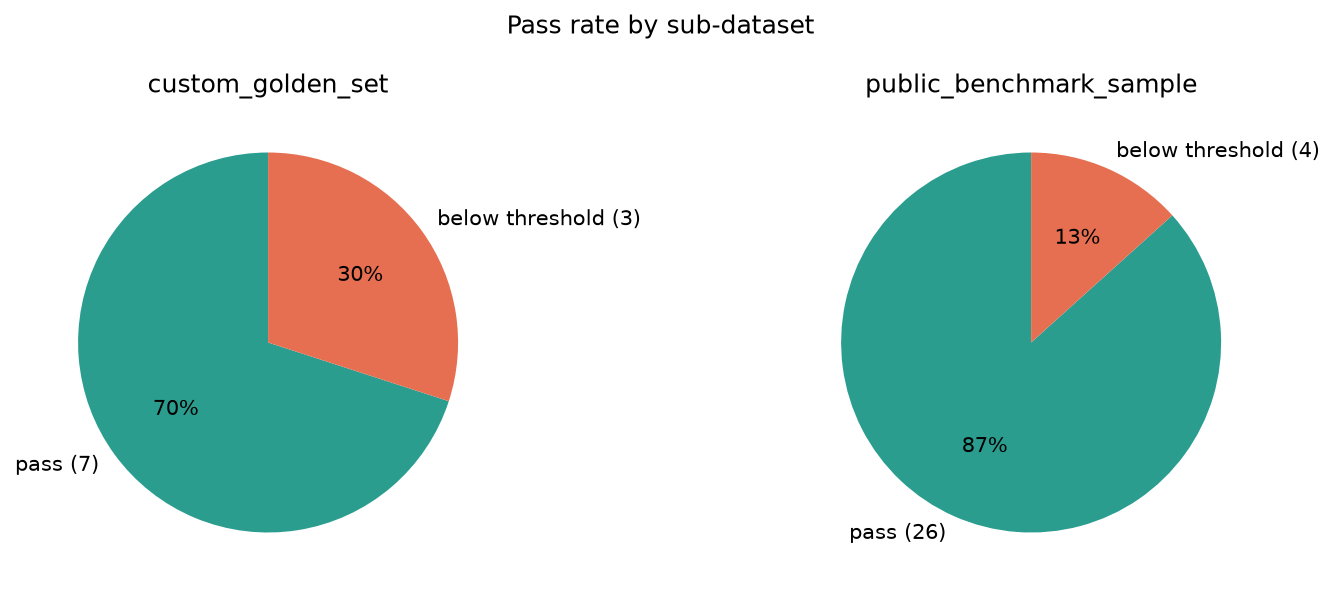
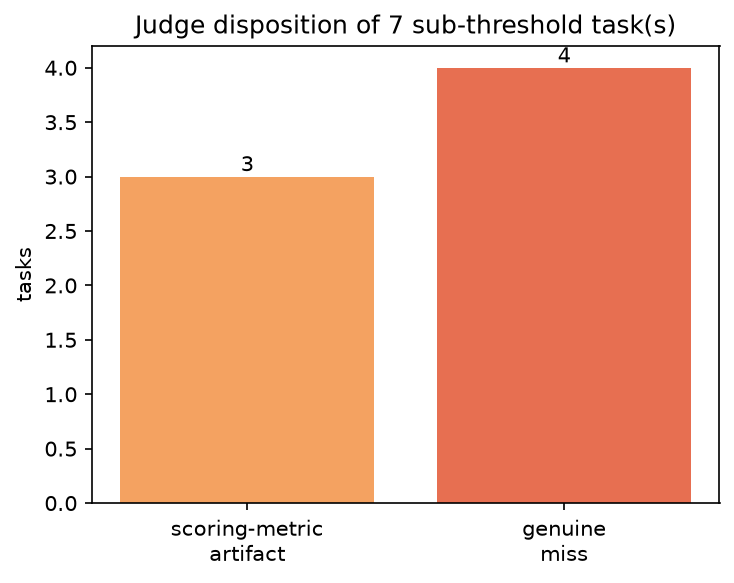

In [14]:
charts = [c for c in [data_chart, score_chart, pass_chart, judge_chart] if c is not None]
report = scenario.build_report(golden_set, public_sample, combined, judged_subset, charts, target_model, api_version)

html = render_report(report)
report_path = save_report(html, "outputs/reports/intended_performance.html")
print(f"Report saved to {report_path}")
embed_report(html)


## 🗂️ Documentation Trail

Every file this run read or produced, checked live (existence, size, last-modified) rather than just listed from memory — the point of an audit trail is that it can be verified, not just claimed. `outputs/runs/` and `outputs/reports/` are gitignored and regenerated on every run; the two fixture files are versioned inputs, not outputs.

In [15]:
artifact_trail(scenario.artifacts(report_path))


,artifact,path,status,size,last modified,description
0,Custom golden set (input),scenarios/fixtures/intended_performance.jsonl,present,6.6KB,2026-07-29 14:37:15,"Hand-authored HR/IT policy Q&A tasks — versioned, not regenerated per run."
1,Public benchmark sample (input),scenarios/fixtures/public_benchmark_sample.jsonl,present,54.1KB,2026-07-29 15:16:00,"Frozen stratified MMLU/TriviaQA/ARC sample (seed 42) — versioned, not regenerated per run."
2,Custom golden set — run output,outputs/runs/intended_performance_v1,present,22.4KB,2026-07-31 13:42:20,"Per-task results, summary, and run metadata from genai_capability_bench (gitignored, regenerated every run)."
3,Public benchmark — run output,outputs/runs/intended_performance_public_benchmark_v1,present,131.8KB,2026-07-31 13:43:24,"Per-task results, summary, and run metadata from genai_capability_bench (gitignored, regenerated every run)."
4,HTML testing report,outputs/reports/intended_performance.html,present,387.0KB,2026-07-31 13:43:35,"The rendered report embedded above — scope, data, results, charts, and judge review."


<a id="how-to-extend"></a>
## 🔧 How to Extend This Scenario

- **Add test cases** — append rows to [`scenarios/fixtures/intended_performance.jsonl`](../scenarios/fixtures/intended_performance.jsonl) (custom golden set) following the existing schema; no code changes needed.
- **Point at a different target model** — edit `.env` (`TARGET_MODEL`, `OPENAI_API_VERSION`); if the new model isn't a reasoning-family model that rejects `temperature`, you may also want to set an explicit `temperature` in `configs/intended_performance*.yaml` instead of leaving it `null`.
- **Change the pass threshold** — edit `pass_thresholds.answer_accuracy` in both `configs/*.yaml` files; `scenario.PASS_THRESHOLD` mirrors it for the judge-review cutoff, so update both together.
- **Add a public-benchmark category** — `scenario.load_public_sample()` reads a frozen fixture; to resample from `genai_capability_bench`'s `curated_knowledge_v1` with different categories or a larger N, see the provenance/regeneration note in [`scenarios/fixtures/public_benchmark_sample_manifest.json`](../scenarios/fixtures/public_benchmark_sample_manifest.json).
- **Change what counts as a scenario-specific chart or report section** — edit [`scenarios/intended_performance.py`](../scenarios/intended_performance.py) directly; this notebook only calls into it, so most changes to *what* gets tested or shown don't require touching the notebook at all.